In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# Evaluation
from sklearn.metrics import silhouette_score

# Dimensionality Reduction
from sklearn.decomposition import PCA

import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset

df = pd.read_csv("03_Clustering_Marketing.csv")
df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [3]:
# Basic Information
df.shape

(15000, 40)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   gradyear         15000 non-null  int64
 1   gender           13663 non-null  str  
 2   age              12504 non-null  str  
 3   NumberOffriends  15000 non-null  int64
 4   basketball       15000 non-null  int64
 5   football         15000 non-null  int64
 6   soccer           15000 non-null  int64
 7   softball         15000 non-null  int64
 8   volleyball       15000 non-null  int64
 9   swimming         15000 non-null  int64
 10  cheerleading     15000 non-null  int64
 11  baseball         15000 non-null  int64
 12  tennis           15000 non-null  int64
 13  sports           15000 non-null  int64
 14  cute             15000 non-null  int64
 15  sex              15000 non-null  int64
 16  sexy             15000 non-null  int64
 17  hot              15000 non-null  int64
 18  kissed           

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gradyear,15000.0,2007.496933,1.116516,2006.0,2006.0,2008.0,2008.0,2009.0
NumberOffriends,15000.0,29.834533,35.386649,0.0,3.0,20.0,44.0,605.0
basketball,15000.0,0.267000,0.788851,0.0,0.0,0.0,0.0,22.0
football,15000.0,0.255467,0.702260,0.0,0.0,0.0,0.0,9.0
soccer,15000.0,0.222000,0.920420,0.0,0.0,0.0,0.0,22.0
softball,15000.0,0.159667,0.737344,0.0,0.0,0.0,0.0,17.0
volleyball,15000.0,0.142933,0.638747,0.0,0.0,0.0,0.0,14.0
swimming,15000.0,0.135000,0.548691,0.0,0.0,0.0,0.0,31.0
cheerleading,15000.0,0.105133,0.502491,0.0,0.0,0.0,0.0,8.0
baseball,15000.0,0.104133,0.519205,0.0,0.0,0.0,0.0,14.0


In [6]:
# Check missing values

df.isnull().sum().sort_values(ascending=False)

age                2496
gender             1337
gradyear              0
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs                 0
dtype: int64

In [7]:
# Converting age data type to numeric

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'].info()

<class 'pandas.Series'>
RangeIndex: 15000 entries, 0 to 14999
Series name: age
Non-Null Count  Dtype  
--------------  -----  
12228 non-null  float64
dtypes: float64(1)
memory usage: 117.3 KB


In [8]:
# missing value Treatment for age

df['age'] = df['age'].fillna(df['age'].median())
df['age'].info()

<class 'pandas.Series'>
RangeIndex: 15000 entries, 0 to 14999
Series name: age
Non-Null Count  Dtype  
--------------  -----  
15000 non-null  float64
dtypes: float64(1)
memory usage: 117.3 KB


In [9]:
# missing vale treatment for gender

df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['gender'].isnull().sum()

np.int64(0)

In [10]:
print(df['gender'].mode())
print(type(df['gender'].mode()[0]))

0    F
Name: gender, dtype: str
<class 'str'>


In [11]:
df['gender'].unique()

<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

In [12]:
# Duplicate check

print("Duplicates:",df.duplicated().sum())


Duplicates: 320


In [13]:
# Drop Duplicates

df.drop_duplicates(inplace = True)

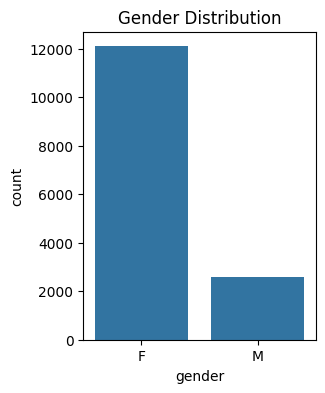

In [14]:
# EDA

# Gender Distribution

plt.figure(figsize=(3,4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()


Interpretation:

The gender distribution analysis reveals that female students are substantially more represented than male students in the dataset. This indicates a gender imbalance, with females constituting the majority of observations. Such an imbalance may influence clustering outcomes and should be considered while interpreting the student segments generated during the clustering process.

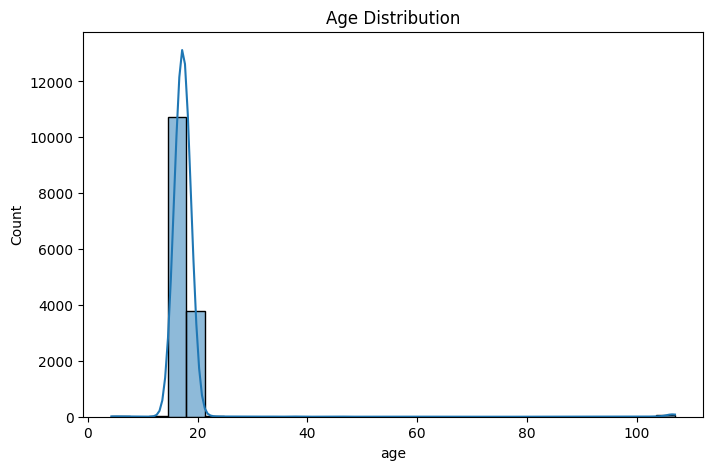

In [15]:
# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

Interpretation:

The age distribution is concentrated between 16 and 20 years, with the highest frequency observed around 17–18 years. The distribution exhibits positive skewness due to the presence of a few extreme age values, including an age above 100, which appears to be an outlier. Since clustering algorithms are sensitive to such anomalies, outlier treatment will be done before model development.

In [16]:
# Checking skewness

num_features = df.select_dtypes(include = np.number).columns
skewness_df = pd.DataFrame({
    'Feature': num_features,
    'Skewness': df[num_features].skew()
}).reset_index(drop=True)

skewness_df.sort_values(by='Skewness', ascending=False)

,Feature,Skewness
29,blonde,115.997556
14,sex,49.473029
26,bible,21.188319
25,jesus,18.965276
8,swimming,16.221784
17,kissed,12.731884
38,drugs,12.375326
20,marching,11.543864
1,age,11.536980
23,god,11.392407


In [17]:
# Transform highly skewed faetures

high_skewed_features = skewness_df[skewness_df['Skewness']>1]['Feature'].tolist()

for col in high_skewed_features:
    df[col] = np.log1p(df[col])

In [18]:
# Verify the skewness

new_skewness = pd.DataFrame({
    'Feature': num_features,
    'Skewness': df[num_features].skew().values
 })

new_skewness.sort_values(by = 'Skewness', ascending = False)

,Feature,Skewness
26,bible,9.754954
1,age,8.084523
20,marching,6.826535
11,tennis,5.554520
29,blonde,5.546253
38,drugs,5.355494
34,abercrombie,5.276062
33,hollister,4.751050
17,kissed,4.675295
10,baseball,4.624928


In [19]:
# Outlier Treatment

continuous_col = ['age','NumberOffriends']

for col in continuous_col:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col} : {outliers} outlier")

age : 196 outlier
NumberOffriends : 0 outlier


In [20]:
# outlier Treatment for age variable

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['age'] = np.where(df['age'] > upper, upper, df['age'])
df['age'] = np.where(df['age'] < lower, lower, df['age'])

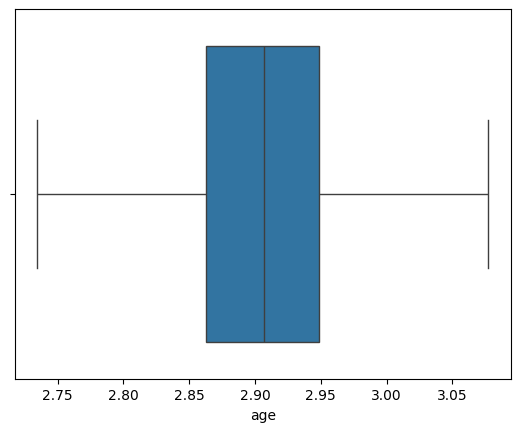

In [21]:
# Verifying the result

sns.boxplot(x = df['age'])
plt.show()

In [22]:
# Label Encoder for gender

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

In [23]:
# Feature Scaling

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data, columns = df.columns
)

scaled_df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,-0.451330,-0.462629,0.020476,-1.746506,-0.411396,-0.42386,-0.309345,-0.271848,-0.275905,-0.317844,...,-0.234651,-0.437580,-0.561783,-0.349973,-0.228828,-0.201984,-0.370934,-0.305136,-0.253184,-0.205600
1,-0.451330,-0.462629,0.123435,0.833310,-0.411396,-0.42386,1.686379,-0.271848,-0.275905,2.361297,...,-0.234651,-0.437580,-0.561783,-0.349973,-0.228828,-0.201984,-0.370934,-0.305136,2.910271,-0.205600
2,-0.451330,-0.462629,0.213330,0.718331,-0.411396,-0.42386,-0.309345,-0.271848,-0.275905,-0.317844,...,-0.234651,1.538996,-0.561783,-0.349973,-0.228828,-0.201984,-0.370934,-0.305136,2.910271,3.635151
3,-1.347277,-0.462629,0.020476,0.634744,-0.411396,-0.42386,-0.309345,-0.271848,-0.275905,-0.317844,...,-0.234651,-0.437580,-0.561783,-0.349973,-0.228828,-0.201984,-0.370934,-0.305136,-0.253184,-0.205600
4,0.444617,-0.462629,-0.562743,-1.289404,-0.411396,-0.42386,-0.309345,-0.271848,-0.275905,2.361297,...,-0.234651,-0.437580,-0.561783,4.774878,-0.228828,-0.201984,-0.370934,-0.305136,-0.253184,-0.205600


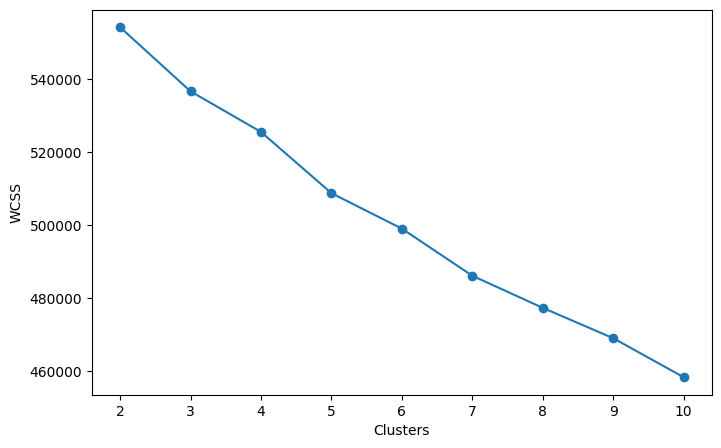

In [24]:
# Find optimal K for K-Means

# Elbow Method

wcss = []                   # within cluster sum of squares

for i in range(2,11):

    kmeans = KMeans(
        n_clusters = i,
        random_state = 42
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker = 'o')

plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

Interpretation:

The Elbow Method was applied to determine the optimal number of clusters for K-Means clustering. The WCSS values showed a decreasing trend as the number of clusters increased. The curve began to flatten around K=5, indicating diminishing returns from adding additional clusters. Therefore, K=5 was selected as the optimal number of clusters. This choice was further validated using the Silhouette Score.

In [25]:
# K-Means Clustering

kmeans = KMeans(
    n_clusters = 5,
    random_state = 42
)

kmeans_labels = kmeans.fit_predict(scaled_df)

df['KMeans_Cluster'] = kmeans_labels



In [26]:
# Silhoutte Score for KMeans 

kmeans_score = silhouette_score(
    scaled_df,
    kmeans_labels
)

print("KMeans Silhoutte Score:", kmeans_score)

KMeans Silhoutte Score: 0.13841651034746152


In [27]:
# Hierarchical Clustering

hierarchical = AgglomerativeClustering(
    n_clusters= 5
)

hier_labels = hierarchical.fit_predict(scaled_df)

df['Hierarchical_Cluster'] = hier_labels

In [28]:
# Silhoutte Score for Hierarchical Clustering

hier_score = silhouette_score(
    scaled_df,
    hier_labels
)

print("Hierarchical Score:", hier_score)

Hierarchical Score: 0.19991479779242477


In [29]:
# DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

db_labels = dbscan.fit_predict(scaled_df)

df['DBSCAN_Cluster'] = db_labels

# Number of clusters

print("Clusters:", len(set(db_labels)) - (1 if -1 in db_labels else 0))

Clusters: 22


In [30]:
# Silhoutte Score for DBSCAN

if len(set(db_labels)) > 1:
    db_score = silhouette_score(
        scaled_df,
        db_labels
    )

else:
    db_score = -1

print("DBSCAN Score:", db_score)

DBSCAN Score: -0.2703260590248115


In [31]:
# Comparing Silhoutte Score when cluster = 5

comparison = pd.DataFrame({
    'Model' : ['KMeans', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score' : [kmeans_score, hier_score, db_score]
})

comparison

,Model,Silhouette Score
0,KMeans,0.138417
1,Hierarchical,0.199915
2,DBSCAN,-0.270326


Interpretation:

Among the three clustering techniques, Hierarchical Clustering achieved the highest Silhouette Score (0.1999), indicating relatively better cluster separation and cohesion compared to K-Means and DBSCAN. K-Means produced a lower score of 0.1384, suggesting weak cluster formation. DBSCAN resulted in a negative Silhouette Score (-0.2703), indicating poor clustering performance with significant overlap among clusters.

Overall, none of the clustering algorithms achieved a high Silhouette Score.

In [32]:
# KMeans : Silhouette Score for Different k

kmeans_score = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters = k,
        random_state= 42
    )

    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(
        scaled_df,
        labels
    )

    kmeans_score.append(score)
    print(f"K={k}, Silhouette Score = {score:.4f}")

K=2, Silhouette Score = 0.2655
K=3, Silhouette Score = 0.1416
K=4, Silhouette Score = 0.2296
K=5, Silhouette Score = 0.1384
K=6, Silhouette Score = 0.1220
K=7, Silhouette Score = 0.0263
K=8, Silhouette Score = 0.0240
K=9, Silhouette Score = 0.0261
K=10, Silhouette Score = 0.0174


In [33]:
# Hierarchical Clustering: Silhouette Score for different k

hier_score = []

for k in range(2,11):

    hierarchical = AgglomerativeClustering(
        n_clusters=k
    )

    labels = hierarchical.fit_predict(scaled_df)

    score = silhouette_score(
        scaled_df,
        labels
    )

    hier_score.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.2330
K=3, Silhouette Score=0.1941
K=4, Silhouette Score=0.1947
K=5, Silhouette Score=0.1999
K=6, Silhouette Score=0.1420
K=7, Silhouette Score=0.1069
K=8, Silhouette Score=0.1094
K=9, Silhouette Score=0.1075
K=10, Silhouette Score=0.0954


In [34]:
# Compairing both for different k

comparison = pd.DataFrame({
    'Cluster' : range(2,11),
    'KMeans' : kmeans_score,
    'Hierarchical' : hier_score
    })
comparison

,Cluster,KMeans,Hierarchical
0,2,0.265465,0.233001
1,3,0.141579,0.194114
2,4,0.229565,0.194730
3,5,0.138417,0.199915
4,6,0.121970,0.142000
5,7,0.026335,0.106893
6,8,0.023998,0.109437
7,9,0.026081,0.107534
8,10,0.017414,0.095371


In [35]:
# DBSCAN for different epsilon values

for eps in [0.5, 1.0, 1.5, 2.0]:

    dbscan = DBSCAN(
        eps = eps,
        min_samples= 5
    )

    labels = dbscan.fit_predict(scaled_df)

    if len(set(labels)) > 1:
        score = silhouette_score(
            scaled_df,
            labels
        )

        print(f"eps={eps}, score={score:.4f}")

eps=0.5, score=-0.3369
eps=1.0, score=-0.3427
eps=1.5, score=-0.2915
eps=2.0, score=-0.2292


Interpretation:

The performance of K-Means, Hierarchical Clustering, and DBSCAN was evaluated using the Silhouette Score across different parameter settings. The highest Silhouette Scores obtained were 0.2655 for K-Means (K=2), 0.2330 for Hierarchical Clustering (K=2), and -0.2292 for DBSCAN (eps=2.0).

Although none of the algorithms achieved a high Silhouette Score, K-Means produced the highest score among all evaluated models and therefore demonstrated comparatively better cluster separation. The relatively low scores suggest that the student profiles do not form naturally distinct groups and that there is substantial overlap in student interests and behavioral characteristics.

Based on the comparative analysis, K-Means with K=2 was selected as the final clustering model because it achieved the best clustering quality among the evaluated approaches. The resulting clusters should be interpreted as broad student segments rather than highly separated groups.

In [36]:
# Build Final K-Means Model 

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(scaled_df)
df.head()


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,hollister,abercrombie,die,death,drunk,drugs,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster,Cluster
0,2007,0,2.906628,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0,0,0,0
1,2007,0,2.912894,3.912023,0.0,0.0,0.693147,0.0,0.0,0.693147,...,0.0,0.0,0.0,0.0,0.693147,0.000000,0,0,-1,0
2,2007,0,2.918365,3.737670,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.693147,0.693147,4,1,-1,1
3,2006,0,2.906628,3.610918,0.0,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0,0,0,0
4,2008,0,2.871132,0.693147,0.0,0.0,0.000000,0.0,0.0,0.693147,...,0.0,0.0,0.0,0.0,0.000000,0.000000,1,0,-1,1


In [37]:
# Check Cluster Distribution

df['Cluster'].value_counts()

Cluster
0    11945
1     2735
Name: count, dtype: int64

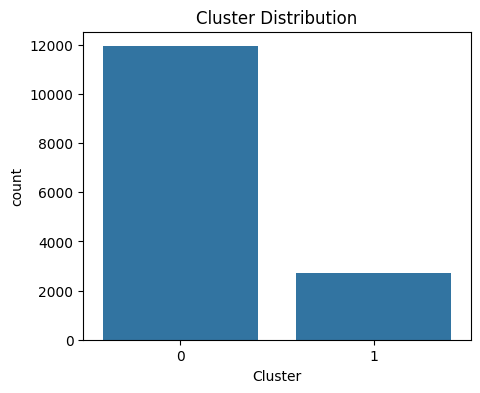

In [38]:
# Visualization

plt.figure(figsize=(5,4))
sns.countplot(x='Cluster', data=df)
plt.title("Cluster Distribution")
plt.show()

In [39]:
# PCA for cluster visulaization

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = df['Cluster']



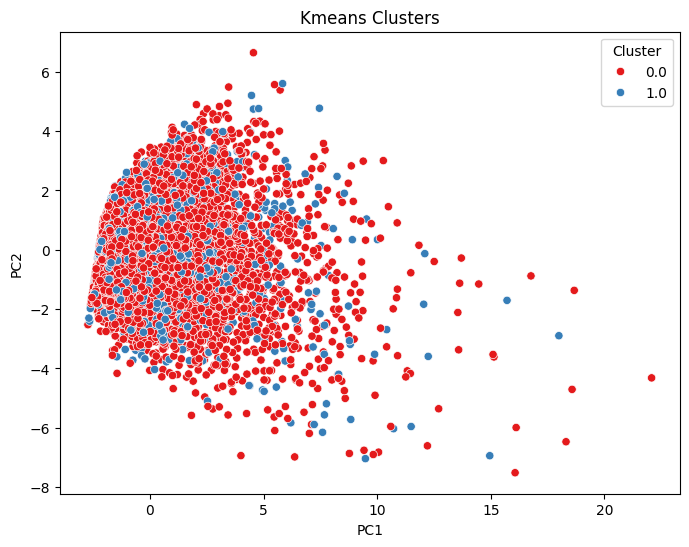

In [40]:
# KMeans Cluster Plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title('Kmeans Clusters')
plt.show()

Interpretation:

The PCA-based cluster visualization was used to represent the K-Means clustering results in two dimensions. The plot shows considerable overlap between Cluster 0 and Cluster 1, indicating that the student profiles do not form clearly distinct groups. Although K-Means achieved the highest Silhouette Score (0.2655) among the evaluated algorithms, the visualization suggests only moderate cluster separation. This implies that students share many common interests and demographic characteristics, resulting in overlapping behavioral segments. Nevertheless, the clustering process was able to identify broad student groups that can be used for segmentation and profiling purposes.

In [41]:
# Student Segmentation

cols_to_drop = ['KMeans_Cluster','Hierarchical_Cluster', 'DBSCAN_Cluster']

profile_df = df.drop(columns= cols_to_drop)
cluster_profile = profile_df.groupby('Cluster').mean().T
cluster_profile

Cluster,0,1
gradyear,2007.434491,2007.806216
gender,0.200837,0.069104
age,2.908866,2.890162
NumberOffriends,2.565379,3.010965
basketball,0.114189,0.304326
football,0.115869,0.294460
soccer,0.087597,0.194105
softball,0.061170,0.165769
volleyball,0.058189,0.157989
swimming,0.059187,0.182884


In [42]:
# Save encoder

joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [43]:
# Save Scaler

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [44]:
# save final model

joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']

In [45]:
# save features names

features_names = df.drop(
    columns = [
        'KMeans_Cluster',
        'Hierarchical_Cluster',
        'DBSCAN_Cluster',
        'Cluster'
    ], errors= 'ignore'
).columns.tolist()

joblib.dump(features_names,'feature_names.pkl')

['feature_names.pkl']

In [46]:
import sklearn

print(sklearn.__version__)

1.9.0
